# MammoLens: Breast Cancer Detection on Mammograms

**Author:** Ibrahim Tamilore Esther

This notebook is a control. The rebuild in v2 gave me a worse model on more data, and one possible reason was that training had stopped early, so here I run exactly the same recipe on exactly the same split with early stopping switched off and let the full 12-epoch schedule finish. Nothing else changes. I call this run v3, and its outputs are in `recovered_data_full_schedule/`.

> `README.md` explains all four runs I did and which one I am reporting as my main result.

> This is an academic prototype. It is not a medical device and it must not be used to make decisions about anyone's care.

<a id="s1"></a>
## 1 Setup and guards

The cell below finds the project, loads the same configuration file my earlier runs used, and points three paths at the v3 folders: checkpoints to `recovered_data_full_schedule/checkpoints/`, logs to `recovered_data_full_schedule/results/logs/` and anything else this notebook saves to `recovered_data_full_schedule/results/` or `recovered_data_full_schedule/figures/`. It then switches early stopping off by setting the patience far above the epoch count, and prints the settings that matter so nobody has to take my word for them.

Then two guards. The first reads the v2 manifests and checks they still hold 2210 training, 445 validation and 430 test images. That matters because the whole point of this run is to change one thing and nothing else; if I had rebuilt the split in between, the comparison would be worthless. The second records the size and modification time of every file in my v1 and v2 folders, so Section 5 can show I did not write into them. I also copy the images to the session's local disk, which my v2 run showed barely helps the speed, but I kept it so the pipeline is identical.

In [2]:
# My v3 experiment: same data, same split, same hyperparameters, same seed,
# with early stopping off so the full 12-epoch cosine schedule finishes.
# I write only inside recovered_data_full_schedule/.
import os, sys, copy, json, time, shutil
import numpy as np
import pandas as pd
import torch

IN_COLAB = 'google.colab' in sys.modules
COLAB_ROOT = '/content/drive/MyDrive/MammoLens'
if IN_COLAB:
    if not os.path.isdir('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
    PROJECT_DIR = COLAB_ROOT
else:
    here = os.getcwd()
    PROJECT_DIR = os.path.dirname(here) if os.path.basename(here) == 'notebooks' else here
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from src.config import load_config, ensure_dirs
cfg3 = load_config('configs/config.yaml')
if not IN_COLAB:
    for k, v in vars(cfg3.paths).items():
        setattr(cfg3.paths, k, v.replace(COLAB_ROOT, PROJECT_DIR))

RES3 = os.path.join(PROJECT_DIR, 'recovered_data_full_schedule', 'results')
CKPT3 = os.path.join(PROJECT_DIR, 'recovered_data_full_schedule', 'checkpoints')
FIG3 = os.path.join(PROJECT_DIR, 'recovered_data_full_schedule', 'figures')
for p in (RES3, CKPT3, FIG3):
    os.makedirs(p, exist_ok=True)
cfg3.paths.checkpoint_dir = CKPT3
cfg3.paths.log_dir = os.path.join(RES3, 'logs')
cfg3.train.early_stopping_patience = 10 ** 6      # the one change I am making: early stopping cannot fire
ensure_dirs(cfg3)

DRIVE_DATA = cfg3.paths.data_dir
LOCAL_DATA = '/content/data' if IN_COLAB else os.path.join(PROJECT_DIR, 'local_cache')
SEED, POS = cfg3.project.seed, cfg3.evaluate.positive_class
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Guard 1: if this is not still the v2 split, the comparison is worthless, so stop.
MANIFESTS = {s: pd.read_csv(os.path.join(DRIVE_DATA, f'{s}.csv')) for s in ('train', 'val', 'test')}
sizes = {s: len(d) for s, d in MANIFESTS.items()}
print('Manifest sizes:', sizes)
assert sizes == {'train': 2210, 'val': 445, 'test': 430}, 'these are not the v2 manifests'
print('Split matches the v2 run, so v2 and v3 differ only in training length.')

# Guard 2: fingerprint my v1 and v2 files now so Section 5 can prove I left them alone.
PROTECTED = ['recovered_data_run', 'initial_run', 'data']
def fingerprint():
    out = {}
    for d in PROTECTED:
        root = os.path.join(PROJECT_DIR, d)
        if not os.path.isdir(root):
            continue
        if d == 'data':
            # only the manifests: walking the 10237 JPEGs over the Drive mount is slow
            # and this notebook never writes an image anywhere.
            entries = [(root, [f for f in os.listdir(root) if os.path.isfile(os.path.join(root, f))])]
        else:
            entries = [(dp, fs) for dp, _, fs in os.walk(root)]
        for dirpath, files in entries:
            for f in files:
                p = os.path.join(dirpath, f)
                out[os.path.relpath(p, PROJECT_DIR)] = (os.path.getsize(p), round(os.path.getmtime(p), 3))
    return out
BEFORE = fingerprint()
print(f'Fingerprinted {len(BEFORE)} files in the v1 and v2 folders.')

print(f'\nDevice: {device}' + (f' ({torch.cuda.get_device_name(0)})' if device.type == 'cuda' else ''))
print(f'Epochs: {cfg3.train.epochs} | early stopping patience: {cfg3.train.early_stopping_patience} (disabled) | '
      f'seed: {SEED}')
print(f'Batch size: {cfg3.train.batch_size} | learning rate: {cfg3.train.learning_rate} | '
      f'weight decay: {cfg3.train.weight_decay} | image size: {cfg3.data.image_size}')
print(f'Checkpoints -> {CKPT3}')

# Local copy, as in my earlier runs. It barely helps the speed, but it keeps the pipeline identical.
if IN_COLAB:
    from concurrent.futures import ThreadPoolExecutor
    rels = pd.concat([d['image_path'] for d in MANIFESTS.values()]).unique()
    def _copy(rel):
        dst = os.path.join(LOCAL_DATA, rel)
        if os.path.isfile(dst):
            return 0
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy(os.path.join(DRIVE_DATA, rel), dst)
        return 1
    with ThreadPoolExecutor(max_workers=8) as ex:
        n_copied = sum(ex.map(_copy, rels))
    print(f'Local copy: {n_copied} copied, {len(rels) - n_copied} already present')
    cfg3.paths.data_dir = LOCAL_DATA
IMG_ROOT = cfg3.paths.data_dir
print('Reading images from', IMG_ROOT)

Mounted at /content/drive
Manifest sizes: {'train': 2210, 'val': 445, 'test': 430}
Split matches the v2 run, so v2 and v3 differ only in training length.
Fingerprinted 33 files in the v1 and v2 folders.

Device: cuda (Tesla T4)
Epochs: 12 | early stopping patience: 1000000 (disabled) | seed: 42
Batch size: 32 | learning rate: 0.0003 | weight decay: 0.0001 | image size: 224
Checkpoints -> /content/drive/MyDrive/MammoLens/checkpoints_v3
Local copy: 3085 copied, 0 already present
Reading images from /content/data


The manifests came back with 2210, 445 and 430 images, so this run is on the v2 split exactly as it was, and the fingerprint covered 33 files across the eight folders I am protecting. Early stopping reports as disabled and everything else matches my earlier runs: 12 epochs, batch size 32, learning rate 0.0003, weight decay 0.0001, 224-pixel inputs and seed 42.

<a id="s2"></a>
## 2 Training with the full schedule

<a id="s2-1"></a>
### 2.1 Retraining

This is my v2 training call with two changes. The patience is high enough that early stopping cannot fire, and the run is tagged `v3` so it writes its own checkpoints and cannot pick up from either of the earlier runs. Everything else, seed included, comes from the same configuration file.

Since the seed and the data are the same, epochs 1 to 10 should follow the v2 log closely. I do not expect them to match to the last digit, because GPU kernels and mixed precision are not bit-deterministic, but a big divergence would tell me something other than training length differs between the two runs, and Section 2.2 checks that directly. Epochs 11 and 12 are the new part: the tail of the cosine schedule that v2 never got to, where the learning rate falls towards zero.

Two checkpoints matter afterwards. `best_model.pt` holds whichever epoch had the highest validation AUC, which is how I selected the model in v1 and v2, and `last_checkpoint.pt` holds epoch 12. Section 3.1 scores both, because the question here is whether finishing the schedule helps, and the answer can differ between the model validation picks and the model the schedule ends on.

In [ ]:
# 2.1 Retrain on the v2 split with early stopping disabled, tagged v3.
from src.train import train

LOG3 = os.path.join(RES3, 'training_log.csv')
t0 = time.time()
model3 = train(cfg3, run_tag='v3', log_csv=LOG3)
print(f'\nTotal wall-clock time: {(time.time() - t0) / 60:.1f} min')

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 01/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 01/12 | train loss 2.2836 auc 0.5704 | val loss 1.7882 auc 0.6056 acc 0.6180 | lr 2.95e-04 |  479s  *best


Epoch 02/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

...

Epoch 10/12 | train loss 0.3416 auc 0.9294 | val loss 0.7795 auc 0.7405 acc 0.6652 | lr 2.01e-05 |  461s


Epoch 11/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 11/12 | train loss 0.3151 auc 0.9401 | val loss 0.7964 auc 0.7479 acc 0.6719 | lr 5.11e-06 |  463s  *best


Epoch 12/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 12/12 | train loss 0.3096 auc 0.9410 | val loss 0.7859 auc 0.7490 acc 0.6719 | lr 0.00e+00 |  458s  *best
Done. Best val AUC = 0.7490 -> /content/drive/MyDrive/MammoLens/checkpoints_v3/best_model.pt

Total wall-clock time: 94.9 min


All 12 epochs ran, so the cosine schedule finished with a final learning rate of 0.00e+00, where v2 had stopped at 2.01e-05. Validation AUC did improve at epochs 11 and 12, ending at 0.7490, which is the best of the run and just above v2's best of 0.7478. Training loss fell from 2.2836 to 0.3096 and training AUC rose to 0.9410. The run took 94.9 minutes.

Two things stand out already. The extra epochs moved validation AUC by about a thousandth while training AUC gained more than a hundredth, so most of what those last two epochs bought was a tighter fit to the training data. And because epoch 12 is now the best epoch, the selected checkpoint and the final-epoch model are the same file, which makes the comparison below simpler: the two columns in Table 2 are identical by construction, not by coincidence.

<a id="s2-2"></a>
### 2.2 Training log and learning curve

The cell reads `recovered_data_full_schedule/results/training_log.csv` back from disk, prints it in full, and lines it up against the v2 log for the ten epochs the two runs share. The mean absolute difference in validation AUC over those epochs is my comparability check: a small number means both runs followed the same path and the only real difference is the two extra epochs. A large one would sink the whole experiment.

The figure plots my training and validation AUC with the v2 validation curve behind them and each run's best epoch marked. It answers the question this notebook exists for: does validation AUC pick up again over epochs 11 and 12, or does it stay on the plateau it hit in v2?

run_tag  epoch train_loss train_auc val_loss val_auc       lr  epoch_seconds
     v3      1     2.2836    0.5704   1.7882  0.6056 3.00e-04          478.8
     v3      2     1.2364    0.6612   0.9921  0.6653 2.95e-04          465.1
     v3      3     0.8891    0.7246   0.7785  0.7210 2.80e-04          458.8
     v3      4     0.7744    0.7603   0.9488  0.7105 2.56e-04          456.3
     v3      5     0.7211    0.7889   0.8132  0.7478 2.25e-04          463.9
     v3      6     0.5639    0.8433   0.7191  0.7397 1.89e-04          466.7
     v3      7     0.4996    0.8693   0.7255  0.7349 1.50e-04          464.7
     v3      8     0.4405    0.8940   0.7706  0.7443 1.11e-04          468.8
     v3      9     0.3526    0.9252   0.7568  0.7476 7.50e-05          462.3
     v3     10     0.3416    0.9294   0.7795  0.7405 4.39e-05          460.7
     v3     11     0.3151    0.9401   0.7964  0.7479 2.01e-05          462.9
     v3     12     0.3096    0.9410   0.7859  0.7490 5.11e-06          457.7

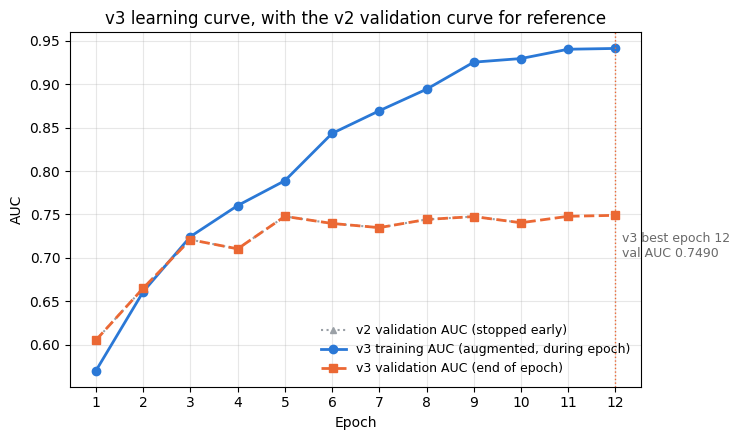

Saved -> /content/drive/MyDrive/MammoLens/figures_v3/training_curve.png


In [ ]:
# 2.2 My log, the ten epochs it shares with v2, and the learning curve.
import matplotlib.pyplot as plt

log3 = pd.read_csv(LOG3)
print(log3.to_string(index=False, formatters={'train_loss': '{:.4f}'.format, 'train_auc': '{:.4f}'.format,
                                              'val_loss': '{:.4f}'.format, 'val_auc': '{:.4f}'.format,
                                              'lr': '{:.2e}'.format}))
best3 = log3.loc[log3['val_auc'].idxmax()]
print(f"\nEpochs completed: {len(log3)} | best validation AUC {best3['val_auc']:.4f} at epoch {int(best3['epoch'])} "
      f"| final epoch validation AUC {log3['val_auc'].iloc[-1]:.4f}")
print(f"Total training time: {log3['epoch_seconds'].sum() / 60:.1f} min "
      f"({log3['epoch_seconds'].mean():.0f} s per epoch)")

log2 = pd.read_csv(os.path.join(PROJECT_DIR, 'recovered_data_run', 'results', 'training_log.csv'))
shared = min(len(log2), len(log3))
cmp_log = pd.DataFrame({'epoch': log3['epoch'][:shared],
                        'v2 val_auc': log2['val_auc'][:shared], 'v3 val_auc': log3['val_auc'][:shared],
                        'v2 train_auc': log2['train_auc'][:shared], 'v3 train_auc': log3['train_auc'][:shared]})
cmp_log['val diff'] = cmp_log['v3 val_auc'] - cmp_log['v2 val_auc']
print(f'\nThe {shared} epochs the two runs share:')
print(cmp_log.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"\nMean absolute validation AUC difference over the shared epochs: {cmp_log['val diff'].abs().mean():.4f}")
best2 = log2.loc[log2['val_auc'].idxmax()]
print(f"v2 best: {best2['val_auc']:.4f} at epoch {int(best2['epoch'])} | "
      f"v3 best: {best3['val_auc']:.4f} at epoch {int(best3['epoch'])}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(log2['epoch'], log2['val_auc'], color='#9aa0a6', marker='^', linestyle=':', linewidth=1.5,
        markersize=5, label='v2 validation AUC (stopped early)')
ax.plot(log3['epoch'], log3['train_auc'], color='#2a78d6', marker='o', linewidth=2, markersize=6,
        label='v3 training AUC (augmented, during epoch)')
ax.plot(log3['epoch'], log3['val_auc'], color='#eb6834', marker='s', linestyle='--', linewidth=2,
        markersize=6, label='v3 validation AUC (end of epoch)')
ax.axvline(int(best3['epoch']), color='#eb6834', linestyle=':', linewidth=1)
ax.annotate(f"v3 best epoch {int(best3['epoch'])}\nval AUC {best3['val_auc']:.4f}",
            xy=(int(best3['epoch']), best3['val_auc']), xytext=(5, -30), textcoords='offset points',
            fontsize=9, color='dimgray')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_xticks(log3['epoch'])
ax.set_title('v3 learning curve, with the v2 validation curve for reference')
ax.legend(loc='lower right', fontsize=9, frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
out = os.path.join(FIG3, 'training_curve.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

<a id="t1"></a>
**Table 1.** My per-epoch log for v3 (`recovered_data_full_schedule/results/training_log.csv`), then the ten epochs shared with v2 side by side, and the mean absolute difference in validation AUC between the two runs.

<a id="f1"></a>
**Figure 1.** Training and validation AUC per epoch for v3, with the v2 validation curve in grey. The dotted line marks the epoch kept as `recovered_data_full_schedule/checkpoints/best_model.pt`. Saved as `recovered_data_full_schedule/figures/training_curve.png`.

The two runs are identical over the ten epochs they share. Every training and validation AUC matches to four decimal places and the mean absolute difference in validation AUC is 0.0000. So the seed, the data and the order of work reproduced exactly, and the only difference between v2 and v3 really is the two extra epochs. That makes this a controlled experiment rather than two runs that happen to look alike, which is more than I expected to get.

Figure 1 shows what those two epochs did. The validation curve, flat from epoch 5 at around 0.74, ends at 0.7490, while the training curve carries on from 0.9294 to 0.9410. The gap between them widens rather than closes. On this figure alone, v2 was not cut off in the middle of useful learning. It was cut off while the model was still fitting its training set and validation had stopped responding.

<a id="s3"></a>
## 3 Evaluation

<a id="s3-1"></a>
### 3.1 Per-image predictions

I repeat Sections 5.6 and 5.7 of my v2 notebook exactly here, so the numbers line up row for row. Every image in the three manifests is scored in evaluation mode with no augmentation, and the malignant probabilities go to `recovered_data_full_schedule/results/`.

I score two models rather than one. The selected checkpoint is what an ordinary run would keep, and it is what my comparison tables use. The final-epoch model is what finishing the schedule actually gives me, and it is the more direct answer to the question I am asking, since validation might well pick an early epoch again. Reporting both means the conclusion does not depend on which one a reader assumes I meant.

In [4]:
# 3.1 Score both checkpoints, the one validation picked and the final epoch, on all three splits.
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, confusion_matrix
from src.data import build_transforms
from src.model import build_model

class EvalImages(Dataset):
    def __init__(self, df, root, image_size):
        self.paths = df['image_path'].tolist()
        self.root = root
        self.tf = build_transforms(image_size, train=False)
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        with Image.open(os.path.join(self.root, self.paths[i])) as im:
            return self.tf(im.convert('RGB'))

mcfg = copy.deepcopy(cfg3)
mcfg.model.pretrained = False

@torch.no_grad()
def score(ckpt_path, df):
    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    net = build_model(mcfg).to(device)
    net.load_state_dict(ck['model_state'])
    net.eval()
    loader = DataLoader(EvalImages(df, IMG_ROOT, cfg3.data.image_size), batch_size=64,
                        shuffle=False, num_workers=cfg3.data.num_workers)
    p = np.concatenate([torch.softmax(net(x.to(device)).float(), 1)[:, POS].cpu().numpy() for x in loader])
    return df.assign(prob_malignant=p)[['patient_id', 'label', 'prob_malignant', 'density', 'image_path']], ck

PRED3, PRED3_FINAL = {}, {}
for tag, ckpt, store, suffix in (('selected (best val AUC)', os.path.join(CKPT3, 'best_model.pt'), PRED3, ''),
                                 ('final epoch', os.path.join(CKPT3, 'last_checkpoint.pt'), PRED3_FINAL, '_final')):
    ck_epoch = None
    for split in ('test', 'train', 'val'):
        t0 = time.time()
        store[split], ck = score(ckpt, MANIFESTS[split])
        ck_epoch = ck['epoch'] + 1
        store[split].to_csv(os.path.join(RES3, f'{split}_predictions{suffix}.csv'), index=False)
    print(f'{tag}: epoch {ck_epoch}, stored val_auc {ck["best_auc"]:.4f} -> recovered_data_full_schedule/results/*_predictions{suffix}.csv')

te = PRED3['test']
auc_te = roc_auc_score(te['label'], te['prob_malignant'])
tn, fp, fn, tp = confusion_matrix(te['label'], (te['prob_malignant'] >= 0.5).astype(int), labels=[0, 1]).ravel()
print(f"\nTest set: {len(te)} images, {int(te['label'].sum())} malignant")
print(f'Selected model test AUC: {auc_te:.4f} | confusion at 0.5: TN {tn} FP {fp} FN {fn} TP {tp}')
assert len(te) == 430, 'unexpected test manifest'

selected (best val AUC): epoch 12, stored val_auc 0.7490 -> results_v3/*_predictions.csv
final epoch: epoch 12, stored val_auc 0.7490 -> results_v3/*_predictions_final.csv

Test set: 430 images, 199 malignant
Selected model test AUC: 0.6694 | confusion at 0.5: TN 171 FP 60 FN 110 TP 89


Both checkpoints turned out to be epoch 12 with a stored validation AUC of 0.7490, so the selected and final-epoch models are the same weights and their predictions are identical. On the test set the model reached an AUC of 0.6694, with 171 true negatives, 60 false positives, 110 false negatives and 89 true positives at a threshold of 0.5.

That confusion matrix looks nothing like v2's on the same 430 images, which had 131 true negatives, 100 false positives, 69 false negatives and 130 true positives (Section 5.6.1 of my v2 notebook). This model is far more cautious at the same nominal threshold: 60 false positives against v2's 100, and 89 true positives against v2's 130. Since the two AUCs are within 0.007 of each other, what moved is where the probabilities sit, not how well the model ranks images. Section 3.5 confirms that.

<a id="s3-2"></a>
### 3.2 Discrimination by split

Table 2 gives AUC on the training, validation and test splits to four decimal places for both v3 models, with the v2 figures next to them. I measure training AUC in evaluation mode on unaugmented images, so it is comparable with the other two and with v2.

This is the first place the experiment can answer its question. If undertraining explained v2, then the extra epochs should pull test AUC up towards v1's 0.7541. If instead they mostly lift training AUC while validation and test stay put, then v2 was not undertrained at all: it was fitting its training set without that fit transferring, and stopping early was the sensible thing to do.

In [5]:
# 3.2 AUC by split for both of my v3 models, with v2 beside them.
V2R = os.path.join(PROJECT_DIR, 'recovered_data_run', 'results')      # read-only here
PRED2 = {s: pd.read_csv(os.path.join(V2R, f'{s}_predictions.csv')) for s in ('train', 'val', 'test')}

rows = []
for split in ('train', 'val', 'test'):
    r = {'split': split, 'N': len(MANIFESTS[split]), 'malignant': int(MANIFESTS[split]['label'].sum())}
    r['v2 AUC'] = roc_auc_score(PRED2[split]['label'], PRED2[split]['prob_malignant'])
    r['v3 selected AUC'] = roc_auc_score(PRED3[split]['label'], PRED3[split]['prob_malignant'])
    r['v3 final AUC'] = roc_auc_score(PRED3_FINAL[split]['label'], PRED3_FINAL[split]['prob_malignant'])
    rows.append(r)
auc_tab = pd.DataFrame(rows)
print(auc_tab.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"\nv3 selected: train minus validation AUC "
      f"{auc_tab.loc[0, 'v3 selected AUC'] - auc_tab.loc[1, 'v3 selected AUC']:+.4f}")
print(f"v3 final:    train minus validation AUC "
      f"{auc_tab.loc[0, 'v3 final AUC'] - auc_tab.loc[1, 'v3 final AUC']:+.4f}")
print(f"v2:          train minus validation AUC "
      f"{auc_tab.loc[0, 'v2 AUC'] - auc_tab.loc[1, 'v2 AUC']:+.4f}")

split    N  malignant  v2 AUC  v3 selected AUC  v3 final AUC
train 2210        993  0.8960           0.9783        0.9783
  val  445        172  0.7498           0.7504        0.7504
 test  430        199  0.6627           0.6694        0.6694

v3 selected: train minus validation AUC +0.2279
v3 final:    train minus validation AUC +0.2279
v2:          train minus validation AUC +0.1462


<a id="t2"></a>
**Table 2.** AUC on each split for the v2 model, my v3 selected checkpoint and my v3 final-epoch model, all measured in evaluation mode without augmentation, with the training minus validation difference for each.

Table 2 answers the question I built this notebook to ask, and the answer is no.

Finishing the schedule raised test AUC from 0.6627 to 0.6694, a change of 0.0067, and validation AUC from 0.7498 to 0.7504, a change of 0.0006. Neither of those means anything beside v1's 0.7541 on its own test set. What the extra epochs did move is training AUC, from 0.8960 to 0.9783, so the training minus validation difference widened from +0.1462 to +0.2279.

That last figure is the one that settles it. v1 had a training AUC of 0.9792 with a validation AUC of 0.7554, which is almost exactly where v3 now sits on the training side at 0.9783. My v2 model had fitted its training data less tightly than v1, and the obvious guess was that this explained the weaker test performance. v3 removes that difference: it fits its training data as hard as v1 did, and still tests at 0.6694 rather than 0.7541. Undertraining was not the explanation.

<a id="s3-3"></a>
### 3.3 Density strata and bootstrap intervals

The density analysis repeats Section 5.7.1 of my v2 notebook with the same settings: 2000 resamples, seed 42, drawn separately inside the non-dense and dense groups, once over images and once over whole patients. Because v3 uses the v2 split, the two groups hold the same images as before, so anything that changes here comes from the model and nothing else.

In [6]:
# 3.3 Bootstrap intervals, over images and then over whole patients, as in my earlier runs.
from scipy.stats import norm

AB, CD = 'non-dense (A/B)', 'dense (C/D)'
THR, N_BOOT = 0.5, 2000

def add_group(df):
    return df.assign(group=np.where(df['density'].isin([1, 2]), AB, CD))

def point_metrics(y, p, thr=THR):
    yhat = p >= thr
    tp = np.sum(yhat & (y == 1)); fn = np.sum(~yhat & (y == 1))
    tn = np.sum(~yhat & (y == 0)); fp = np.sum(yhat & (y == 0))
    return roc_auc_score(y, p), tp / (tp + fn), tn / (tn + fp)

def stratified_bootstrap(gA, gC, n_boot, seed, unit):
    rng = np.random.default_rng(seed)
    data = {}
    for k, g in ((AB, gA), (CD, gC)):
        clusters = list(g.groupby('patient_id').indices.values()) if unit == 'patient' else None
        data[k] = (g['label'].to_numpy(), g['prob_malignant'].to_numpy(), clusters)
    out = {AB: [], CD: [], 'all': []}
    while len(out['all']) < n_boot:
        draw = {}
        for k in (AB, CD):
            y, p, clusters = data[k]
            if clusters is None:
                idx = rng.integers(0, len(y), len(y))
            else:
                pick = rng.integers(0, len(clusters), len(clusters))
                idx = np.concatenate([clusters[i] for i in pick])
            draw[k] = (y[idx], p[idx])
        if min(min(yy.sum(), (1 - yy).sum()) for yy, _ in draw.values()) == 0:
            continue
        for k in (AB, CD):
            out[k].append(point_metrics(*draw[k]))
        out['all'].append(point_metrics(np.r_[draw[AB][0], draw[CD][0]], np.r_[draw[AB][1], draw[CD][1]]))
    return {k: np.array(v) for k, v in out.items()}

test3 = add_group(PRED3['test'])
G3 = {AB: test3[test3['group'] == AB].reset_index(drop=True),
      CD: test3[test3['group'] == CD].reset_index(drop=True)}
print(f"Test images {len(test3)} from {test3['patient_id'].nunique()} patients | "
      f"{AB}: {len(G3[AB])} images | {CD}: {len(G3[CD])} images | "
      f"patients in both groups: {len(set(G3[AB]['patient_id']) & set(G3[CD]['patient_id']))}")

BOOT_IMG = stratified_bootstrap(G3[AB], G3[CD], N_BOOT, SEED, 'image')
BOOT_PAT = stratified_bootstrap(G3[AB], G3[CD], N_BOOT, SEED, 'patient')
POINT3 = {'all': point_metrics(test3['label'].to_numpy(), test3['prob_malignant'].to_numpy()),
          AB: point_metrics(G3[AB]['label'].to_numpy(), G3[AB]['prob_malignant'].to_numpy()),
          CD: point_metrics(G3[CD]['label'].to_numpy(), G3[CD]['prob_malignant'].to_numpy())}

STAT_ROWS = []
rows = []
for k, d in (('all', test3), (AB, G3[AB]), (CD, G3[CD])):
    for j, metric in enumerate(('AUC', 'sensitivity', 'specificity')):
        lo_i, hi_i = np.percentile(BOOT_IMG[k][:, j], [2.5, 97.5])
        lo_p, hi_p = np.percentile(BOOT_PAT[k][:, j], [2.5, 97.5])
        rows.append({'stratum': k, 'N': len(d), 'pos': int(d['label'].sum()), 'metric': metric,
                     'v3 estimate': f'{POINT3[k][j]:.3f}',
                     '95% CI (image)': f'[{lo_i:.3f}, {hi_i:.3f}]',
                     '95% CI (patient)': f'[{lo_p:.3f}, {hi_p:.3f}]'})
        STAT_ROWS += [{'section': '3.3', 'stratum': k, 'metric': metric, 'unit': u,
                       'value': POINT3[k][j], 'ci_low': lo, 'ci_high': hi}
                      for u, lo, hi in (('image', lo_i, hi_i), ('patient', lo_p, hi_p))]
print()
print(pd.DataFrame(rows).to_string(index=False))

Test images 430 from 225 patients | non-dense (A/B): 207 images | dense (C/D): 223 images | patients in both groups: 0

        stratum   N  pos      metric v3 estimate 95% CI (image) 95% CI (patient)
            all 430  199         AUC       0.669 [0.618, 0.719]   [0.611, 0.725]
            all 430  199 sensitivity       0.447 [0.377, 0.518]   [0.376, 0.519]
            all 430  199 specificity       0.740 [0.683, 0.795]   [0.677, 0.800]
non-dense (A/B) 207  104         AUC       0.703 [0.632, 0.771]   [0.618, 0.777]
non-dense (A/B) 207  104 sensitivity       0.452 [0.360, 0.553]   [0.354, 0.554]
non-dense (A/B) 207  104 specificity       0.757 [0.670, 0.840]   [0.663, 0.843]
    dense (C/D) 223   95         AUC       0.636 [0.561, 0.708]   [0.551, 0.714]
    dense (C/D) 223   95 sensitivity       0.442 [0.340, 0.545]   [0.341, 0.543]
    dense (C/D) 223   95 specificity       0.727 [0.648, 0.803]   [0.648, 0.802]


<a id="t3"></a>
**Table 3.** Test-set AUC, sensitivity and specificity at a threshold of 0.5 for my v3 selected model, with 95% percentile bootstrap intervals from 2000 resamples drawn within each density group, resampling images and, separately, whole patients.

Table 3 puts intervals round the v3 numbers, and they sit almost on top of v2's. Aggregate AUC is 0.669 [0.618, 0.719] at image level and [0.611, 0.725] at patient level, against v2's 0.663, whose intervals are in Table 9 of my v2 notebook. Non-dense and dense AUCs are 0.703 and 0.636, against 0.707 and 0.632 in v2. Every interval here overlaps its v2 counterpart across nearly its whole width.

Sensitivity and specificity moved in opposite directions, which the confusion matrix in Section 3.1 had already hinted at: sensitivity fell to 0.447 [0.377, 0.518] from v2's 0.653, and specificity rose to 0.740 [0.683, 0.795] from 0.567. At a fixed threshold of 0.5 the two models trade the same ranking ability for a different balance of errors. As in v2, the patient-level intervals are wider than the image-level ones, which is what I would expect when 430 images come from 225 patients.

<a id="s3-4"></a>
### 3.4 Testing the density gap

The gap test repeats Section 5.7.2 of my v2 notebook with nothing changed: the difference between the non-dense and dense AUCs, a bootstrap interval from the two independently resampled groups, an unpaired z-test using the bootstrap standard errors, then the patient-level version and the closed-form standard errors of Hanley and McNeil (1982) beside it. DeLong's paired test does not apply here, because the two groups hold different patients.

My v1 run found a gap of 0.1238 with p = 0.0116, and v2 found 0.0750 with p = 0.1518. A third estimate, on the same test set as v2 but from a model trained for longer, shows how much of that movement follows the model rather than the data.

In [7]:
# 3.4 The density gap: unpaired, because the two groups hold different patients.
aucA, aucC = POINT3[AB][0], POINT3[CD][0]
diff3 = aucA - aucC

def z_test(d, se_a, se_c):
    z = d / np.hypot(se_a, se_c)
    return z, 2 * norm.sf(abs(z))

def hanley_mcneil_se(auc, n_pos, n_neg):
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return np.sqrt((auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2)
                    + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg))

yA, yC = G3[AB]['label'].to_numpy(), G3[CD]['label'].to_numpy()
methods = []
for name, boot in (('image-level bootstrap (primary)', BOOT_IMG), ('patient-level bootstrap', BOOT_PAT)):
    bd = boot[AB][:, 0] - boot[CD][:, 0]
    se_a, se_c = boot[AB][:, 0].std(ddof=1), boot[CD][:, 0].std(ddof=1)
    z, p = z_test(diff3, se_a, se_c)
    methods.append((name, np.percentile(bd, [2.5, 97.5]), (se_a, se_c), z, p))
se_hm = (hanley_mcneil_se(aucA, int(yA.sum()), int((1 - yA).sum())),
         hanley_mcneil_se(aucC, int(yC.sum()), int((1 - yC).sum())))
z_hm, p_hm = z_test(diff3, *se_hm)
methods.append(('Hanley-McNeil SE (normal CI)',
                (diff3 - 1.96 * np.hypot(*se_hm), diff3 + 1.96 * np.hypot(*se_hm)), se_hm, z_hm, p_hm))

print(f'v3: AUC {AB} = {aucA:.4f} | AUC {CD} = {aucC:.4f} | difference = {diff3:.4f}\n')
print(f"{'method':<34}{'95% CI of difference':>24}{'SE A/B':>9}{'SE C/D':>9}{'z':>8}{'p (two-sided)':>15}")
for name, ci, se, z, p in methods:
    print(f"{name:<34}{f'[{ci[0]:.4f}, {ci[1]:.4f}]':>24}{se[0]:>9.4f}{se[1]:>9.4f}{z:>8.3f}{p:>15.4f}")
    STAT_ROWS.append({'section': '3.4', 'stratum': 'A/B minus C/D', 'metric': f'gap: {name}',
                      'unit': '', 'value': diff3, 'ci_low': ci[0], 'ci_high': ci[1],
                      'z': z, 'p': p})
GAP3 = {'diff': diff3, 'image': methods[0], 'patient': methods[1], 'hm': methods[2]}
print(f"\nPrimary test: {'significant' if methods[0][4] < 0.05 else 'not significant'} at the 0.05 level "
      f"(p = {methods[0][4]:.4f}).")
print('For reference: v1 gap 0.1238 (p = 0.0116), v2 gap 0.0750 (p = 0.1518), both from the same code.')

v3: AUC non-dense (A/B) = 0.7029 | AUC dense (C/D) = 0.6356 | difference = 0.0673

method                                95% CI of difference   SE A/B   SE C/D       z  p (two-sided)
image-level bootstrap (primary)          [-0.0279, 0.1743]   0.0357   0.0371   1.306         0.1915
patient-level bootstrap                  [-0.0432, 0.1737]   0.0405   0.0412   1.165         0.2439
Hanley-McNeil SE (normal CI)             [-0.0352, 0.1698]   0.0361   0.0379   1.286         0.1983

Primary test: not significant at the 0.05 level (p = 0.1915).
For reference: v1 gap 0.1238 (p = 0.0116), v2 gap 0.0750 (p = 0.1518), both from the same code.


<a id="t4"></a>
**Table 4.** The non-dense minus dense AUC difference for v3, with its bootstrap interval and unpaired z-test at image and patient level, and the closed-form Hanley and McNeil standard errors as a check.

The gap is 0.0673 and it is not significant: z = 1.306 with p = 0.1915 at image level, z = 1.165 with p = 0.2439 at patient level, and p = 0.1983 from the Hanley and McNeil standard errors. All three intervals include zero.

That gives me three estimates of the same thing from the same code: 0.1238 with p = 0.0116 in v1, 0.0750 with p = 0.1518 in v2, and 0.0673 with p = 0.1915 here. The v2 and v3 estimates come from the same test set with models that rank images almost identically, so their agreement is expected and is not independent confirmation of anything. What matters is that the only run to find a significant gap is still v1, on a different and smaller test set, and that both runs on the larger test set put the gap at roughly half v1's estimate with intervals spanning zero. I do not think this project establishes a density effect, and I would treat the v1 result as one estimate rather than a finding.

<a id="s3-5"></a>
### 3.5 Operating points and calibration

These two checks finish the repeat of Section 5.7. The operating-point table gives sensitivity at a fixed specificity of 0.80, with the threshold fitted on the test set and then, more honestly, fitted on the validation set and applied to the test set. The calibration panel sorts the predicted probabilities into ten equal-width bins and reports the expected calibration error for each density group, which in v2 was 0.1835 for non-dense and 0.2893 for dense images.

Calibration is worth watching in this particular run. Training for longer with a decaying learning rate tends to make a model more confident, so the extra epochs could improve the ranking while making the probabilities less trustworthy, or they could leave both alone.

        stratum  threshold source threshold test specificity test sensitivity  TP  FN  TN  FP
            all       test-fitted  0.598633            0.801            0.407  81 118 185  46
            all validation-fitted  0.576374            0.784            0.407  81 118 181  50
non-dense (A/B)       test-fitted  0.587571            0.816            0.433  45  59  84  19
non-dense (A/B) validation-fitted  0.407250            0.709            0.510  53  51  73  30
    dense (C/D)       test-fitted  0.677767            0.805            0.326  31  64 103  25
    dense (C/D) validation-fitted  0.758317            0.852            0.263  25  70 109  19

non-dense (A/B): ECE = 0.2292
    bin  n mean_pred frac_malignant
0.0-0.1 69     0.028          0.304
0.1-0.2 19     0.150          0.579
0.2-0.3 14     0.243          0.500
0.3-0.4 22     0.354          0.545
0.4-0.5 11     0.464          0.545
0.5-0.6 10     0.561          0.200
0.6-0.7 11     0.661          0.636
0.7-0.8  9     0.762   

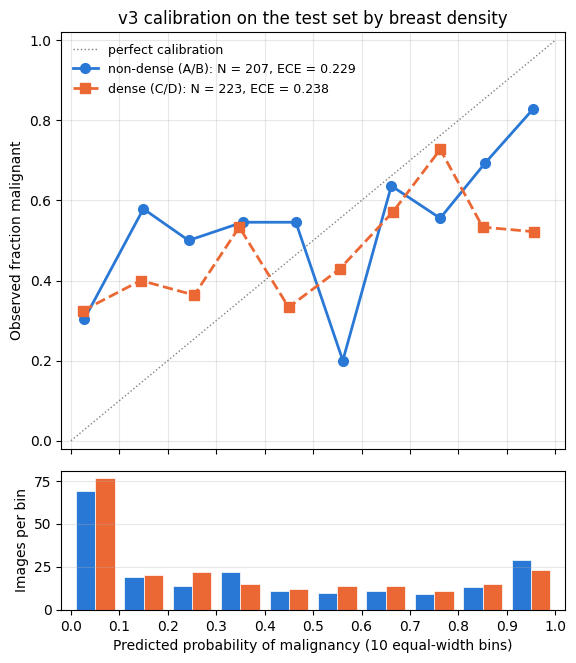


v2 for reference: ECE 0.1835 (non-dense) and 0.2893 (dense)
Saved -> /content/drive/MyDrive/MammoLens/figures_v3/calibration_by_density.png


In [9]:
# 3.5 Sensitivity at a fixed specificity of 0.80, and how trustworthy the probabilities are.
import matplotlib.pyplot as plt

TARGET_SPEC = 0.80

def threshold_at_spec(y, p, target=TARGET_SPEC):
    neg = p[y == 0]
    for t in np.unique(np.r_[p, np.inf]):
        if np.mean(neg < t) >= target:
            return t

def rates(y, p, t):
    yhat = p >= t
    tp = int(np.sum(yhat & (y == 1))); fn = int(np.sum(~yhat & (y == 1)))
    tn = int(np.sum(~yhat & (y == 0))); fp = int(np.sum(yhat & (y == 0)))
    return tn / (tn + fp), tp / (tp + fn), tp, fn, tn, fp

val3 = add_group(PRED3['val'])
test_sets = {'all': test3, AB: G3[AB], CD: G3[CD]}
val_sets = {'all': val3, AB: val3[val3['group'] == AB], CD: val3[val3['group'] == CD]}
rows = []
for k in ('all', AB, CD):
    y, p = test_sets[k]['label'].to_numpy(), test_sets[k]['prob_malignant'].to_numpy()
    for source, fit in (('test-fitted', test_sets[k]), ('validation-fitted', val_sets[k])):
        t = threshold_at_spec(fit['label'].to_numpy(), fit['prob_malignant'].to_numpy())
        spec, sens, tp, fn, tn, fp = rates(y, p, t)
        rows.append({'stratum': k, 'threshold source': source, 'threshold': t,
                     'test specificity': spec, 'test sensitivity': sens,
                     'TP': tp, 'FN': fn, 'TN': tn, 'FP': fp})
        STAT_ROWS.append({'section': '3.5', 'stratum': k, 'metric': f'sensitivity at spec 0.80 ({source})',
                          'unit': '', 'value': sens, 'ci_low': np.nan, 'ci_high': np.nan})
op3 = pd.DataFrame(rows)
op3.to_csv(os.path.join(RES3, 'operating_points.csv'), index=False)
print(op3.to_string(index=False, formatters={'threshold': '{:.6f}'.format,
                                             'test specificity': '{:.3f}'.format,
                                             'test sensitivity': '{:.3f}'.format}))

EDGES = np.linspace(0, 1, 11)
def reliability(y, p):
    b = np.digitize(p, EDGES[1:-1])
    t = pd.DataFrame({'bin': [f'{EDGES[i]:.1f}-{EDGES[i + 1]:.1f}' for i in range(10)],
                      'n': [int(np.sum(b == i)) for i in range(10)],
                      'mean_pred': [p[b == i].mean() if np.any(b == i) else np.nan for i in range(10)],
                      'frac_malignant': [y[b == i].mean() if np.any(b == i) else np.nan for i in range(10)]})
    return t, np.nansum(t['n'] / len(y) * (t['frac_malignant'] - t['mean_pred']).abs())

STYLE = {AB: dict(color='#2a78d6', marker='o', linestyle='-'),
         CD: dict(color='#eb6834', marker='s', linestyle='--')}
fig, (ax, axn) = plt.subplots(2, 1, figsize=(6.5, 7.5), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1, label='perfect calibration')
ECE3 = {}
for j, k in enumerate((AB, CD)):
    tab, ece = reliability(G3[k]['label'].to_numpy(), G3[k]['prob_malignant'].to_numpy())
    ECE3[k] = ece
    STAT_ROWS.append({'section': '3.5', 'stratum': k, 'metric': 'ECE', 'unit': '',
                      'value': ece, 'ci_low': np.nan, 'ci_high': np.nan})
    ok = tab['n'] > 0
    ax.plot(tab.loc[ok, 'mean_pred'], tab.loc[ok, 'frac_malignant'], linewidth=2, markersize=7,
            label=f'{k}: N = {len(G3[k])}, ECE = {ece:.3f}', **STYLE[k])
    axn.bar((EDGES[:-1] + EDGES[1:]) / 2 + (j - 0.5) * 0.04, tab['n'], width=0.04,
            color=STYLE[k]['color'], edgecolor='white', linewidth=0.5)
    print(f'\n{k}: ECE = {ece:.4f}')
    print(tab.to_string(index=False, formatters={'mean_pred': '{:.3f}'.format,
                                                 'frac_malignant': '{:.3f}'.format}))
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_ylabel('Observed fraction malignant')
ax.set_title('v3 calibration on the test set by breast density')
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.grid(alpha=0.3)
axn.set_ylabel('Images per bin')
axn.set_xlabel('Predicted probability of malignancy (10 equal-width bins)')
axn.set_xticks(EDGES)
axn.grid(axis='y', alpha=0.3)
out = os.path.join(FIG3, 'calibration_by_density.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('\nv2 for reference: ECE 0.1835 (non-dense) and 0.2893 (dense)')
print('Saved ->', out)

<a id="t5"></a>
**Table 5.** Sensitivity at a target specificity of 0.80 for my v3 selected model, with the threshold fitted on the test set and on the validation set, followed by the per-bin calibration tables and the expected calibration error for each density group.

<a id="f2"></a>
**Figure 2.** Reliability diagram for my v3 selected model: non-dense in blue circles with a solid line, dense in orange squares with a dashed line, ten equal-width bins, and the per-bin counts below. Saved as `recovered_data_full_schedule/figures/calibration_by_density.png`.

At a fixed specificity of 0.80 this model does what v2 did. Sensitivity is 0.407 overall with a test-fitted threshold and 0.407 with the validation-fitted one, identical to v2 on both counts. In non-dense breasts it is 0.433 test-fitted and 0.510 validation-fitted, against the 0.433 and 0.500 in Table 10 of my v2 notebook; in dense breasts 0.326 and 0.263, against the 0.358 and 0.305 reported there. The thresholds themselves are much lower than v2's, 0.598633 overall against the 0.863134 v2 needed, which again is the probability scale shifting rather than the ranking changing.

Calibration did not improve. The expected calibration error is 0.2292 for non-dense images, worse than v2's 0.1835, and 0.2378 for dense images, better than v2's 0.2893. Both curves stay far from the diagonal: images given a probability below 0.1 turn out malignant in 0.304 of non-dense cases and 0.325 of dense ones, and the top bin only reaches 0.828 and 0.522. Training to the end of the schedule with the learning rate decaying to zero left this model no better calibrated, and slightly worse on the non-dense group.

<a id="s4"></a>
## 4 Three-way comparison

I do the comparison in three parts, in increasing order of how much weight each one can carry.

The three-way table sets v1, v2 and v3 side by side on every metric I have reported. It is the widest view, but v1 is measured on a different test set from v2 and v3, so its column cannot be read directly against the others on test metrics.

The paired comparison against v1 uses only the images both runs held out, which neither model trained on. It is the same 48 images my v2 notebook used, because v3 inherits the v2 split, and the interval round it is wide.

The paired comparison between v2 and v3 is the strongest evidence in this notebook. Those two models share a test set of 430 images exactly, so the comparison is paired image by image, the bootstrap resamples images jointly for both models, and nothing about the data differs between them. If finishing the schedule recovers performance, this is where it shows.

In [10]:
# 4 My three runs side by side, plus the two paired comparisons.
V1R = os.path.join(PROJECT_DIR, 'recovered_data_run', 'results', 'v1_rescored')    # written by the v2 run, read-only
V1MAN = os.path.join(PROJECT_DIR, 'initial_run', 'manifests')
PRED1 = {s: pd.read_csv(os.path.join(V1R, f'{s}_predictions.csv')) for s in ('train', 'val', 'test')}

def summarise(pred_by_split, seed=SEED):
    te = add_group(pred_by_split['test'])
    gA, gC = te[te['group'] == AB].reset_index(drop=True), te[te['group'] == CD].reset_index(drop=True)
    out = {}
    for s in ('train', 'val', 'test'):
        p = pred_by_split[s]
        out[f'{s} AUC'] = roc_auc_score(p['label'], p['prob_malignant'])
        out[f'{s} images'] = len(p)
    for name, d in (('all', te), (AB, gA), (CD, gC)):
        auc, sens, spec = point_metrics(d['label'].to_numpy(), d['prob_malignant'].to_numpy())
        out[f'AUC {name}'], out[f'sensitivity {name}'], out[f'specificity {name}'] = auc, sens, spec
        out[f'N {name}'] = len(d)
    bi = stratified_bootstrap(gA, gC, N_BOOT, seed, 'image')
    bp = stratified_bootstrap(gA, gC, N_BOOT, seed, 'patient')
    diff = out[f'AUC {AB}'] - out[f'AUC {CD}']
    lo_i, hi_i = np.percentile(bi[AB][:, 0] - bi[CD][:, 0], [2.5, 97.5])
    lo_p, hi_p = np.percentile(bp[AB][:, 0] - bp[CD][:, 0], [2.5, 97.5])
    z_i, p_i = z_test(diff, bi[AB][:, 0].std(ddof=1), bi[CD][:, 0].std(ddof=1))
    z_p, p_p = z_test(diff, bp[AB][:, 0].std(ddof=1), bp[CD][:, 0].std(ddof=1))
    out.update({'density gap (A/B minus C/D)': diff,
                'gap CI low (image)': lo_i, 'gap CI high (image)': hi_i, 'gap p (image)': p_i,
                'gap CI low (patient)': lo_p, 'gap CI high (patient)': hi_p, 'gap p (patient)': p_p})
    return out

S1, S2, S3 = summarise(PRED1), summarise(PRED2), summarise(PRED3)
S3F = summarise(PRED3_FINAL)
three = pd.DataFrame([{'metric': k, 'v1': S1.get(k), 'v2': S2.get(k),
                       'v3 selected': S3.get(k), 'v3 final epoch': S3F.get(k)} for k in S3])
three['v3 selected minus v2'] = three['v3 selected'] - three['v2']

def paired_diff(y, pa, pb, seed=SEED, n=N_BOOT):
    # AUC(b) - AUC(a) on the same images, resampled jointly.
    rng = np.random.default_rng(seed)
    out = []
    while len(out) < n:
        idx = rng.integers(0, len(y), len(y))
        if 0 < y[idx].sum() < len(idx):
            out.append(roc_auc_score(y[idx], pb[idx]) - roc_auc_score(y[idx], pa[idx]))
    return np.percentile(out, [2.5, 97.5])

# (a) v3 against v1, using only images both runs held out
common = sorted(set(PRED3['test']['image_path']) & set(PRED1['test']['image_path']))
print(f'Images held out by both the v1 and the v3 run: {len(common)}')
if len(common) >= 20:
    a = PRED1['test'].set_index('image_path').loc[common]
    b = PRED3['test'].set_index('image_path').loc[common]
    y = b['label'].to_numpy()
    auc1 = roc_auc_score(y, a['prob_malignant']); auc3 = roc_auc_score(y, b['prob_malignant'])
    lo, hi = paired_diff(y, a['prob_malignant'].to_numpy(), b['prob_malignant'].to_numpy())
    print(f'Common subset (N = {len(common)}, {int(y.sum())} malignant): v1 AUC {auc1:.4f} | '
          f'v3 AUC {auc3:.4f} | paired difference {auc3 - auc1:+.4f} [95% CI {lo:+.4f}, {hi:+.4f}]')
    STAT_ROWS.append({'section': '4', 'stratum': f'common subset with v1 (N={len(common)})',
                      'metric': 'v3 minus v1 AUC', 'unit': 'paired', 'value': auc3 - auc1,
                      'ci_low': lo, 'ci_high': hi})

# (b) v3 against v2 on the shared test set, which is the strongest comparison I have.
# I align on image_path rather than trusting the row order, so a partial overlap
# gets reported instead of crashing the cell after 90 minutes of training.
pair = (PRED2['test'][['image_path', 'label', 'prob_malignant']]
        .merge(PRED3['test'][['image_path', 'prob_malignant']], on='image_path', suffixes=('_v2', '_v3'))
        .merge(PRED3_FINAL['test'][['image_path', 'prob_malignant']].rename(
            columns={'prob_malignant': 'prob_final'}), on='image_path'))
print(f"\nImages in both the v2 and v3 test sets: {len(pair)} of {len(PRED3['test'])}")
assert len(pair) >= 20, 'the v2 and v3 test sets barely overlap; check that both used the same split'
if len(pair) < len(PRED3['test']):
    print('WARNING: the two test sets are not identical, so this comparison uses their intersection.')
y = pair['label'].to_numpy()
p2, p3, p3f = (pair['prob_malignant_v2'].to_numpy(), pair['prob_malignant_v3'].to_numpy(),
               pair['prob_final'].to_numpy())
auc2, auc3, auc3f = roc_auc_score(y, p2), roc_auc_score(y, p3), roc_auc_score(y, p3f)
lo, hi = paired_diff(y, p2, p3)
lo_f, hi_f = paired_diff(y, p2, p3f)
print(f'Same {len(pair)} test images, v2 against v3 selected: v2 AUC {auc2:.4f} | v3 AUC {auc3:.4f} | '
      f'paired difference {auc3 - auc2:+.4f} [95% CI {lo:+.4f}, {hi:+.4f}]')
print(f'Same {len(pair)} test images, v2 against v3 final epoch: v3 final AUC {auc3f:.4f} | '
      f'paired difference {auc3f - auc2:+.4f} [95% CI {lo_f:+.4f}, {hi_f:+.4f}]')
for tag, d, lo_, hi_ in (('v3 selected minus v2', auc3 - auc2, lo, hi),
                         ('v3 final minus v2', auc3f - auc2, lo_f, hi_f)):
    STAT_ROWS.append({'section': '4', 'stratum': f'shared test set (N={len(pair)})', 'metric': tag,
                      'unit': 'paired', 'value': d, 'ci_low': lo_, 'ci_high': hi_})

three.to_csv(os.path.join(RES3, 'v1_v2_v3_comparison.csv'), index=False)
pd.DataFrame(STAT_ROWS).to_csv(os.path.join(RES3, 'stat_tests.csv'), index=False)
print('\n' + three.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\nSaved -> recovered_data_full_schedule/results/v1_v2_v3_comparison.csv and .../stat_tests.csv')

Images held out by both the v1 and the v3 run: 48
Common subset (N = 48, 22 malignant): v1 AUC 0.7622 | v3 AUC 0.6626 | paired difference -0.0997 [95% CI -0.2470, +0.0440]

Images in both the v2 and v3 test sets: 430 of 430
Same 430 test images, v2 against v3 selected: v2 AUC 0.6627 | v3 AUC 0.6694 | paired difference +0.0067 [95% CI -0.0307, +0.0405]
Same 430 test images, v2 against v3 final epoch: v3 final AUC 0.6694 | paired difference +0.0067 [95% CI -0.0307, +0.0405]

                     metric        v1        v2  v3 selected  v3 final epoch  v3 selected minus v2
                  train AUC    0.9792    0.8960       0.9783          0.9783                0.0822
               train images 2052.0000 2210.0000    2210.0000       2210.0000                0.0000
                    val AUC    0.7554    0.7498       0.7504          0.7504                0.0006
                 val images  405.0000  445.0000     445.0000        445.0000                0.0000
                   test AUC

<a id="t6"></a>
**Table 6.** v1, v2 and v3 on every metric, with my v3 final-epoch model in its own column and the change from v2 to the v3 selected model. The v1 column is measured on the v1 test set, so its test metrics are not directly comparable; the two paired comparisons above the table are. Saved as `recovered_data_full_schedule/results/v1_v2_v3_comparison.csv`.

Table 6 and the two paired comparisons all say the same thing: finishing the schedule did not recover v2's performance.

The direct comparison is the strongest evidence I have anywhere in this project. v2 and v3 were scored on the same 430 test images, every one of them common to both, and the paired difference in AUC is +0.0067 with a 95% interval of [-0.0307, +0.0405]. That interval sits close to zero and is narrow enough to rule out any recovery worth the name. For scale, closing the distance to v1 would have needed roughly 0.09.

Against v1, on the 48 images both of those runs held out, v3 scores 0.6626 against v1's 0.7622, a paired difference of -0.0997 with an interval of [-0.2470, +0.0440]. The matching v2 figure, from Table 11 of my v2 notebook, was -0.1801 with an interval of [-0.3389, -0.0247]. It would be wrong to read that as v3 closing part of the gap. The v2 and v3 models rank these images almost identically, as the 430-image comparison shows, and 48 images give intervals wide enough for two estimates to drift that far apart by resampling alone. The honest summary is that both v2 and v3 are worse than v1 on the shared images, somewhere in the region of 0.10 to 0.18 in AUC, and that 48 images cannot pin it down more tightly than that.

Sensitivity and specificity cannot be compared across the three runs at a fixed 0.5 threshold, because each model places its probabilities differently: sensitivity runs 0.6568, 0.6533 and 0.4472 while specificity runs 0.7446, 0.5671 and 0.7403. AUC and the operating points at fixed specificity are the comparable quantities, and both say the same thing.

So two of my three explanations for the v2 result survive. It is not that the model was undertrained, and it is not that the schedule was cut short. What is left is the unevenness of the v2 split, where the validation set has a much lower malignant share than the test set (Table 4 of my v2 notebook), and the change in the training distribution from 228 recovered images belonging to 105 patients no earlier run had seen. I separated those two in the next experiment, `MammoLens_original_split_with_recovered_images.ipynb`, which adds the recovered images to my v1 partitions and leaves the split otherwise alone. It reached a test AUC of 0.7527, against 0.6694 here and 0.7541 for v1, and its paired difference against v1 on the 400 images both held out was -0.0041 with a 95% interval of [-0.0421, +0.0343]. So the recovered images are not what cost this run its performance. The re-split is.

<a id="s5"></a>
## 5 Verification that v1 and v2 were not touched

The last cell re-fingerprints every file in `recovered_data_run/results/`, `recovered_data_run/checkpoints/`, `recovered_data_run/figures/`, `data/` and my four v1 folders, and compares the result with the fingerprint from Section 1. Anything added, removed or changed in size or modification time gets listed. This checks the notebook as a whole rather than any single cell, because one stray write to a shared path would invalidate every comparison in Section 4.

In [11]:
# 5 Prove I wrote nothing outside recovered_data_full_schedule/.
AFTER = fingerprint()
added = sorted(set(AFTER) - set(BEFORE))
removed = sorted(set(BEFORE) - set(AFTER))
changed = sorted(k for k in set(BEFORE) & set(AFTER) if BEFORE[k] != AFTER[k])
print(f'Files checked: {len(AFTER)} across {len(PROTECTED)} protected folders')
print(f'  added:   {added if added else "none"}')
print(f'  removed: {removed if removed else "none"}')
print(f'  changed: {changed if changed else "none"}')
assert not (added or removed or changed), 'this notebook modified a v1 or v2 artefact'
print('\nOK: the v1 and v2 artefacts are byte-for-byte as they were before this run.')
print('v3 wrote:', {d: sorted(os.listdir(os.path.join(PROJECT_DIR, 'recovered_data_full_schedule', d)))
                    for d in ('results', 'checkpoints', 'figures')})

Files checked: 33 across 8 protected folders
  added:   none
  removed: none
  changed: none

OK: the v1 and v2 artefacts are byte-for-byte as they were before this run.
v3 wrote: {'results_v3': ['logs', 'operating_points.csv', 'stat_tests.csv', 'test_predictions.csv', 'test_predictions_final.csv', 'train_predictions.csv', 'train_predictions_final.csv', 'training_log.csv', 'v1_v2_v3_comparison.csv', 'val_predictions.csv', 'val_predictions_final.csv'], 'checkpoints_v3': ['best_model.pt', 'last_checkpoint.pt'], 'figures_v3': ['calibration_by_density.png', 'training_curve.png']}


The check passed. Of the 33 files I track across the eight protected folders, none was added, removed or changed. My v1 and v2 artefacts are exactly as they were, and every v3 output went to `recovered_data_full_schedule/results/`, `recovered_data_full_schedule/checkpoints/` or `recovered_data_full_schedule/figures/`. That means all three runs can be compared again later from what is on disk, rather than depending on this session.